# Vector Auto Regresive (VAR)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('../Data/gold/epidemics.csv')
df.head()

,week,dengue,zika,chik,var,date,tavg,tmin,tmax,prcp,wdir,wspd,pres,mob_index,google_physician,google_hospital,google_pharmacy,google_symptom
0,2020-03-23,949,3.0,1.0,351.0,2020-03-23,20.003080,14.529673,25.878470,1.866561,180.781498,10.676055,1014.549139,7.531667,28,10,6,44
1,2020-03-30,1006,1.0,4.0,275.0,2020-03-30,20.310320,15.607637,25.801951,4.628407,82.957584,10.251907,1013.957489,4.344286,31,8,6,40
2,2020-04-06,931,3.0,2.0,212.0,2020-04-06,20.567575,15.800335,25.874548,3.028124,54.720690,10.745449,1014.803952,2.705714,40,8,6,38
3,2020-04-13,883,1.0,0.0,188.0,2020-04-13,19.564572,14.112981,25.608096,2.240946,158.256566,9.985720,1016.499355,1.977143,27,8,5,31
4,2020-04-20,879,3.0,3.0,195.0,2020-04-20,19.833153,14.608703,25.966335,4.637722,121.429786,8.996266,1015.642953,2.207143,24,7,5,29


In [3]:
df['date'] = pd.to_datetime(df['date'])

In [4]:
df.columns

Index(['week', 'dengue', 'zika', 'chik', 'var', 'date', 'tavg', 'tmin', 'tmax',
       'prcp', 'wdir', 'wspd', 'pres', 'mob_index', 'google_physician',
       'google_hospital', 'google_pharmacy', 'google_symptom'],
      dtype='object')

# Experiment

In [5]:
df_var = df[['date',  'dengue', 'tavg',
       'prcp', 'wspd', 'pres', 'mob_index', 
       'google_hospital', 'google_pharmacy', 'google_symptom']]
df_var.set_index('date', inplace=True)

In [6]:
import statsmodels.api as sm
from statsmodels.tsa.api import VAR

In [7]:
# Fit a VAR model
model = VAR(df_var)
results = model.fit(maxlags=5)  # Choose lag length (5 lags)
print(results.summary())

  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Fri, 28, Mar, 2025
Time:                     09:41:57
--------------------------------------------------------------------
No. of Equations:         9.00000    BIC:                    17.3451
Nobs:                     192.000    HQIC:                   13.1659
Log likelihood:          -3028.75    FPE:                    33076.7
AIC:                      10.3211    Det(Omega_mle):         4786.75
--------------------------------------------------------------------
Results for equation dengue
                        coefficient       std. error           t-stat            prob
-------------------------------------------------------------------------------------
const                   -633.046565      5992.574789           -0.106           0.916
L1.dengue                  0.771170         0.082911            9.301           0.000
L1.tavg                   13.225368    

c:\Users\danie\anaconda3\envs\thesis\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-MON will be used.
  self._init_dates(dates, freq)


In [10]:
# log of variables
df_var_log = np.log(df_var).diff()
df_var_log.dropna(inplace=True)
df_var_log.head()


,dengue,tavg,prcp,wspd,pres,mob_index,google_hospital,google_pharmacy,google_symptom
date,,,,,,,,,
2020-03-30,0.058329,0.015243,0.908115,-0.040540,-0.000583,-0.550255,-0.223144,0.000000,-0.095310
2020-04-06,-0.077478,0.012587,-0.424269,0.047019,0.000834,-0.473495,0.000000,0.000000,-0.051293
2020-04-13,-0.052934,-0.049995,-0.301046,-0.073326,0.001669,-0.313713,0.000000,-0.182322,-0.203599
2020-04-20,-0.004540,0.013635,0.727325,-0.104346,-0.000843,0.110046,-0.133531,0.000000,-0.066691
2020-04-27,-0.092924,0.022462,-0.703587,0.106406,-0.000401,0.182322,0.133531,0.000000,0.000000


In [11]:
# Fit a VAR model
model_l = VAR(df_var_log)
results_l = model_l.fit(maxlags=5)  # Choose lag length (5 lags)
results_l.summary()

c:\Users\danie\anaconda3\envs\thesis\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-MON will be used.
  self._init_dates(dates, freq)


  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Fri, 28, Mar, 2025
Time:                     09:42:52
--------------------------------------------------------------------
No. of Equations:         9.00000    BIC:                   -43.6340
Nobs:                     191.000    HQIC:                  -47.8281
Log likelihood:           2815.11    FPE:                1.06216e-22
AIC:                     -50.6834    Det(Omega_mle):     1.52319e-23
--------------------------------------------------------------------
Results for equation dengue
                        coefficient       std. error           t-stat            prob
-------------------------------------------------------------------------------------
const                      0.004269         0.006726            0.635           0.526
L1.dengue                 -0.194546         0.078673           -2.473           0.013
L1.tavg                    0.349934    

# All countries

In [12]:
def extract_significant_vars(results, target, alpha=0.05):
    # Get the parameters, standard errors, t-statistics, and p-values

    
    params = results.params[target]
    stderr = results.stderr[target]
    tvalues = results.tvalues[target]
    pvalues = results.pvalues[target]

    # Combine into a DataFrame
    df = pd.DataFrame({
        'Variable': params.index,
        'Coefficient': params.values,
        'Std. Error': stderr.values,
        't-value': tvalues.values,
        'P-value': pvalues.values
    })

        # Filter significant variables (p-value < alpha)
    significant_df = df[df['P-value'] < alpha]

    return significant_df


In [13]:
extract_significant_vars(results_l, 'dengue')

,Variable,Coefficient,Std. Error,t-value,P-value
1,L1.dengue,-0.194546,0.078673,-2.472834,0.013405
10,L2.dengue,0.179638,0.078519,2.287817,0.022148
19,L3.dengue,0.203366,0.076480,2.659064,0.007836
20,L3.tavg,1.020368,0.471488,2.164142,0.030453
22,L3.wspd,-0.281819,0.121855,-2.312743,0.020737
23,L3.pres,23.753508,8.299976,2.861877,0.004211
27,L3.google_symptom,-0.212236,0.094568,-2.244268,0.024815
38,L5.tavg,-1.509244,0.440897,-3.423124,0.000619


In [37]:
df.columns

Index(['week', 'dengue', 'zika', 'chik', 'var', 'date', 'tavg', 'tmin', 'tmax',
       'prcp', 'wdir', 'wspd', 'pres', 'mob_index', 'google_physician',
       'google_hospital', 'google_pharmacy', 'google_symptom',
       'dengue_cumulative', 'zika_cumulative', 'chik_cumulative',
       'var_cumulative'],
      dtype='object')

In [36]:
targets = [ 'dengue', 'zika', 'chik', 'var']
for col in targets:
    df[col+'_cumulative'] = np.cumsum(df[col])

In [38]:
#targets = [ 'dengue', 'zika', 'chik', 'var']
targets = ['dengue_cumulative', 'zika_cumulative', 'chik_cumulative',
       'var_cumulative']

dict_results = {}
#target = 'new_cases'
# loop mock
for target in targets:
    print(target)
    df_var = df[['date',  target, 'tavg',
       'prcp', 'wspd', 'pres', 'mob_index', 
       'google_hospital', 'google_pharmacy', 'google_symptom']]
    df_var.set_index('date', inplace=True)
    df_var[target] = df_var[target].replace(0,1)
    df_var_log = np.log(df_var).diff()
    df_var_log.dropna(inplace=True)
    model_l = VAR(df_var_log)
    results_l = model_l.fit(maxlags=5)  # Choose lag length (5 lags)
    significant_vars_cases = extract_significant_vars(results_l, target=target, alpha=0.05)
    dict_results[target] = significant_vars_cases['Variable'].values


dengue_cumulative
zika_cumulative
chik_cumulative
var_cumulative


C:\Users\danie\AppData\Local\Temp\ipykernel_25120\2514230786.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_var[target] = df_var[target].replace(0,1)
c:\Users\danie\anaconda3\envs\thesis\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-MON will be used.
  self._init_dates(dates, freq)
C:\Users\danie\AppData\Local\Temp\ipykernel_25120\2514230786.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_var[target] = d

In [39]:
df_results = pd.DataFrame.from_dict(dict_results, orient='index').T
df_results

,dengue_cumulative,zika_cumulative,chik_cumulative,var_cumulative
0,const,L1.zika_cumulative,const,const
1,L1.dengue_cumulative,L1.prcp,L2.pres,L1.var_cumulative
2,L2.dengue_cumulative,L2.zika_cumulative,L3.chik_cumulative,None
3,L3.pres,L2.pres,L4.chik_cumulative,None
4,L5.tavg,L2.google_pharmacy,L5.chik_cumulative,None
5,None,L3.zika_cumulative,None,None
6,None,L3.tavg,None,None
7,None,L4.zika_cumulative,None,None
8,None,L4.tavg,None,None


In [40]:
target = 'dengue_cumulative'


df_var = df[['date',  target, 'tavg',
        'wspd', 'pres', 'google_symptom']]
df_var.set_index('date', inplace=True)

df_var[target] = df_var[target].replace(0,1)
df_var_log = np.log(df_var).diff()
df_var_log.dropna(inplace=True)
model_l = VAR(df_var_log)
results_l = model_l.fit(maxlags=5)  # Choose lag length (5 lags)
irf = results_l.irf(10)


C:\Users\danie\AppData\Local\Temp\ipykernel_25120\1920733354.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_var[target] = df_var[target].replace(0,1)
c:\Users\danie\anaconda3\envs\thesis\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-MON will be used.
  self._init_dates(dates, freq)


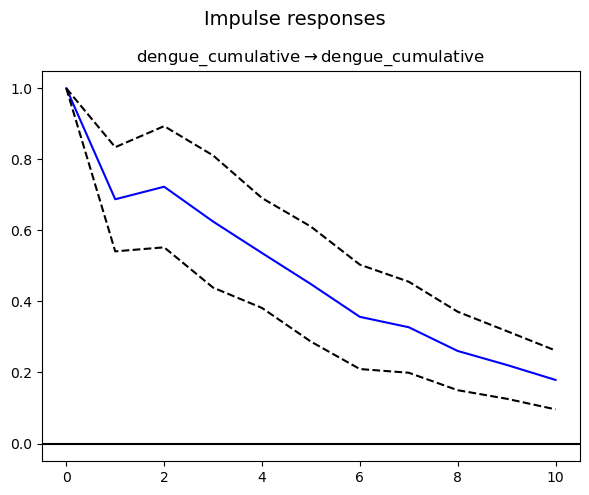

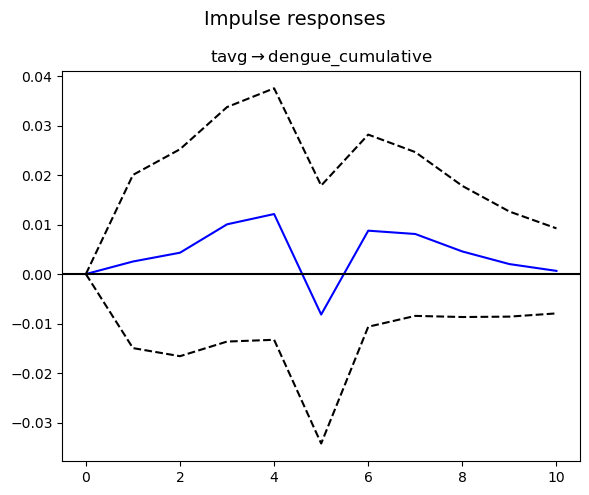

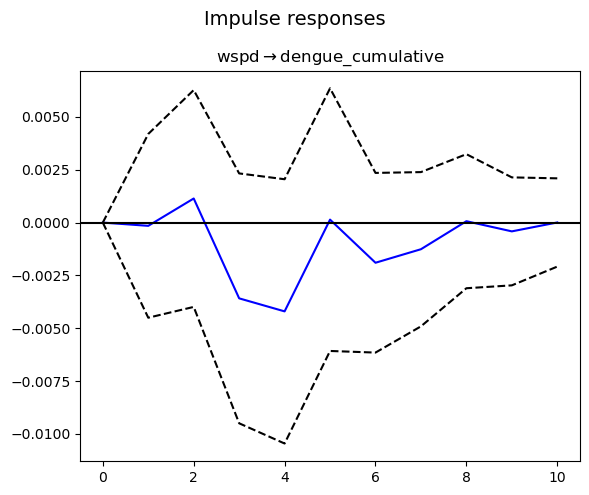

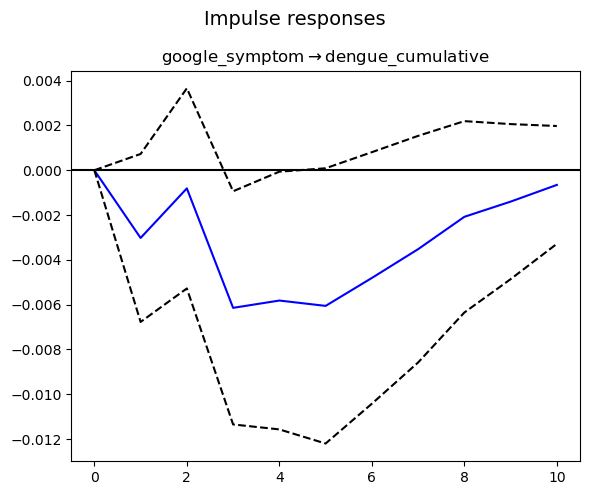

In [41]:
impulses = [target, 'tavg','wspd', 'google_symptom']
response = target  # e.g., 'dengue'

for imp in impulses:
    irf.plot(impulse=imp, response=response, figsize=(6, 5))  # smaller plot size
    plt.tight_layout()

    


# Train Test split

Processing disease: dengue_cumulative
Processing disease: zika_cumulative
Processing disease: chik_cumulative
Processing disease: var_cumulative


C:\Users\danie\AppData\Local\Temp\ipykernel_25120\1430170895.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_var.replace(0, 1, inplace=True)
c:\Users\danie\anaconda3\envs\thesis\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-MON will be used.
  self._init_dates(dates, freq)
C:\Users\danie\AppData\Local\Temp\ipykernel_25120\1430170895.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_var.replace(0, 1, inplace=True)
c:\Users\danie\anaconda3\envs\thesis\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning:

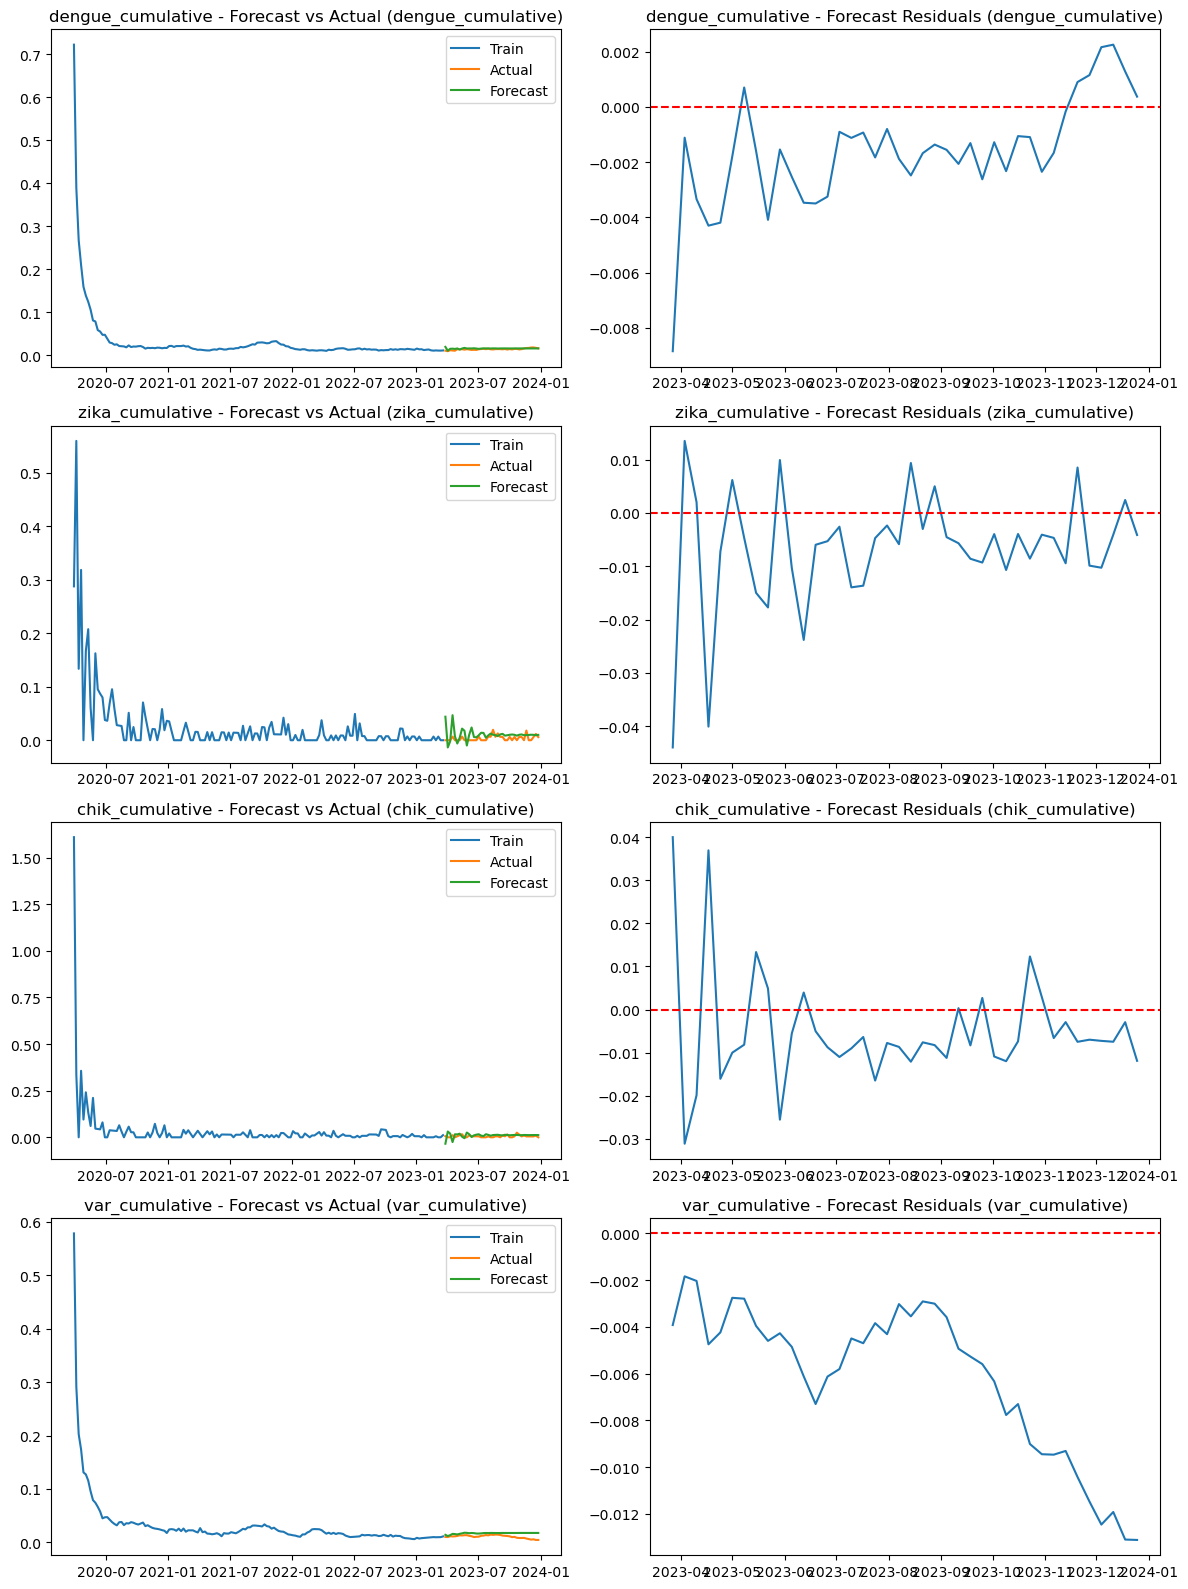

In [42]:
from sklearn.metrics import mean_squared_error, r2_score


dict_metrics = {}

fig, axs = plt.subplots(len(targets), 2, figsize=(12, 4 * len(targets)))

for idx, target in enumerate(targets):
    print(f"Processing disease: {target}")

    # select variables
    df_var = df[['date',  target, 'tavg',
    'prcp', 'wspd', 'pres', 'mob_index', 
    'google_hospital', 'google_pharmacy', 'google_symptom']]
    df_var.set_index('date', inplace=True)

    
    # replace 0 to avoid log error
    df_var.replace(0, 1, inplace=True)

    # log difference
    df_var_log = np.log(df_var).diff().dropna()

    # train-test split
    split_idx = int(len(df_var_log) * 0.8)
    df_train, df_test = df_var_log.iloc[:split_idx], df_var_log.iloc[split_idx:]

    # fit VAR model on training data
    model_l = VAR(df_train)
    results_l = model_l.fit(maxlags=5)

    # Forecasting
    lag_order = results_l.k_ar
    forecast_input = df_train.values[-lag_order:]
    forecast_steps = len(df_test)

    forecast = results_l.forecast(y=forecast_input, steps=forecast_steps)
    forecast_df = pd.DataFrame(forecast, index=df_test.index, columns=df_test.columns)

    # Calculate performance metrics
    rmse = np.sqrt(mean_squared_error(df_test[target], forecast_df[target]))
    r2 = r2_score(df_test[target], forecast_df[target])

    dict_metrics[target] = {'rmse': rmse, 'r2': r2}

    # Plot actual vs forecast for target variable
    axs[idx, 0].plot(df_train[target], label='Train')
    axs[idx, 0].plot(df_test[target], label='Actual')
    axs[idx, 0].plot(forecast_df[target], label='Forecast')
    axs[idx, 0].set_title(f'{target} - Forecast vs Actual ({target})')
    axs[idx, 0].legend()

    # Plot residuals
    residuals = df_test[target] - forecast_df[target]
    axs[idx, 1].plot(residuals)
    axs[idx, 1].axhline(y=0, color='r', linestyle='--')
    axs[idx, 1].set_title(f'{target} - Forecast Residuals ({target})')

plt.tight_layout()
plt.show()

In [43]:
# Display metrics
metrics_df = pd.DataFrame(dict_metrics).T
metrics_df

,rmse,r2
dengue_cumulative,0.002556,-0.841987
zika_cumulative,0.012910,-5.615077
chik_cumulative,0.013949,-5.228019
var_cumulative,0.006916,-5.035418


Processing disease: dengue_cumulative
Processing disease: zika_cumulative
Processing disease: chik_cumulative
Processing disease: var_cumulative


C:\Users\danie\AppData\Local\Temp\ipykernel_25120\424648570.py:27: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_var.replace(0, 1, inplace=True)
c:\Users\danie\anaconda3\envs\thesis\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-MON will be used.
  self._init_dates(dates, freq)
C:\Users\danie\AppData\Local\Temp\ipykernel_25120\424648570.py:27: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_var.replace(0, 1, inplace=True)
c:\Users\danie\anaconda3\envs\thesis\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: N

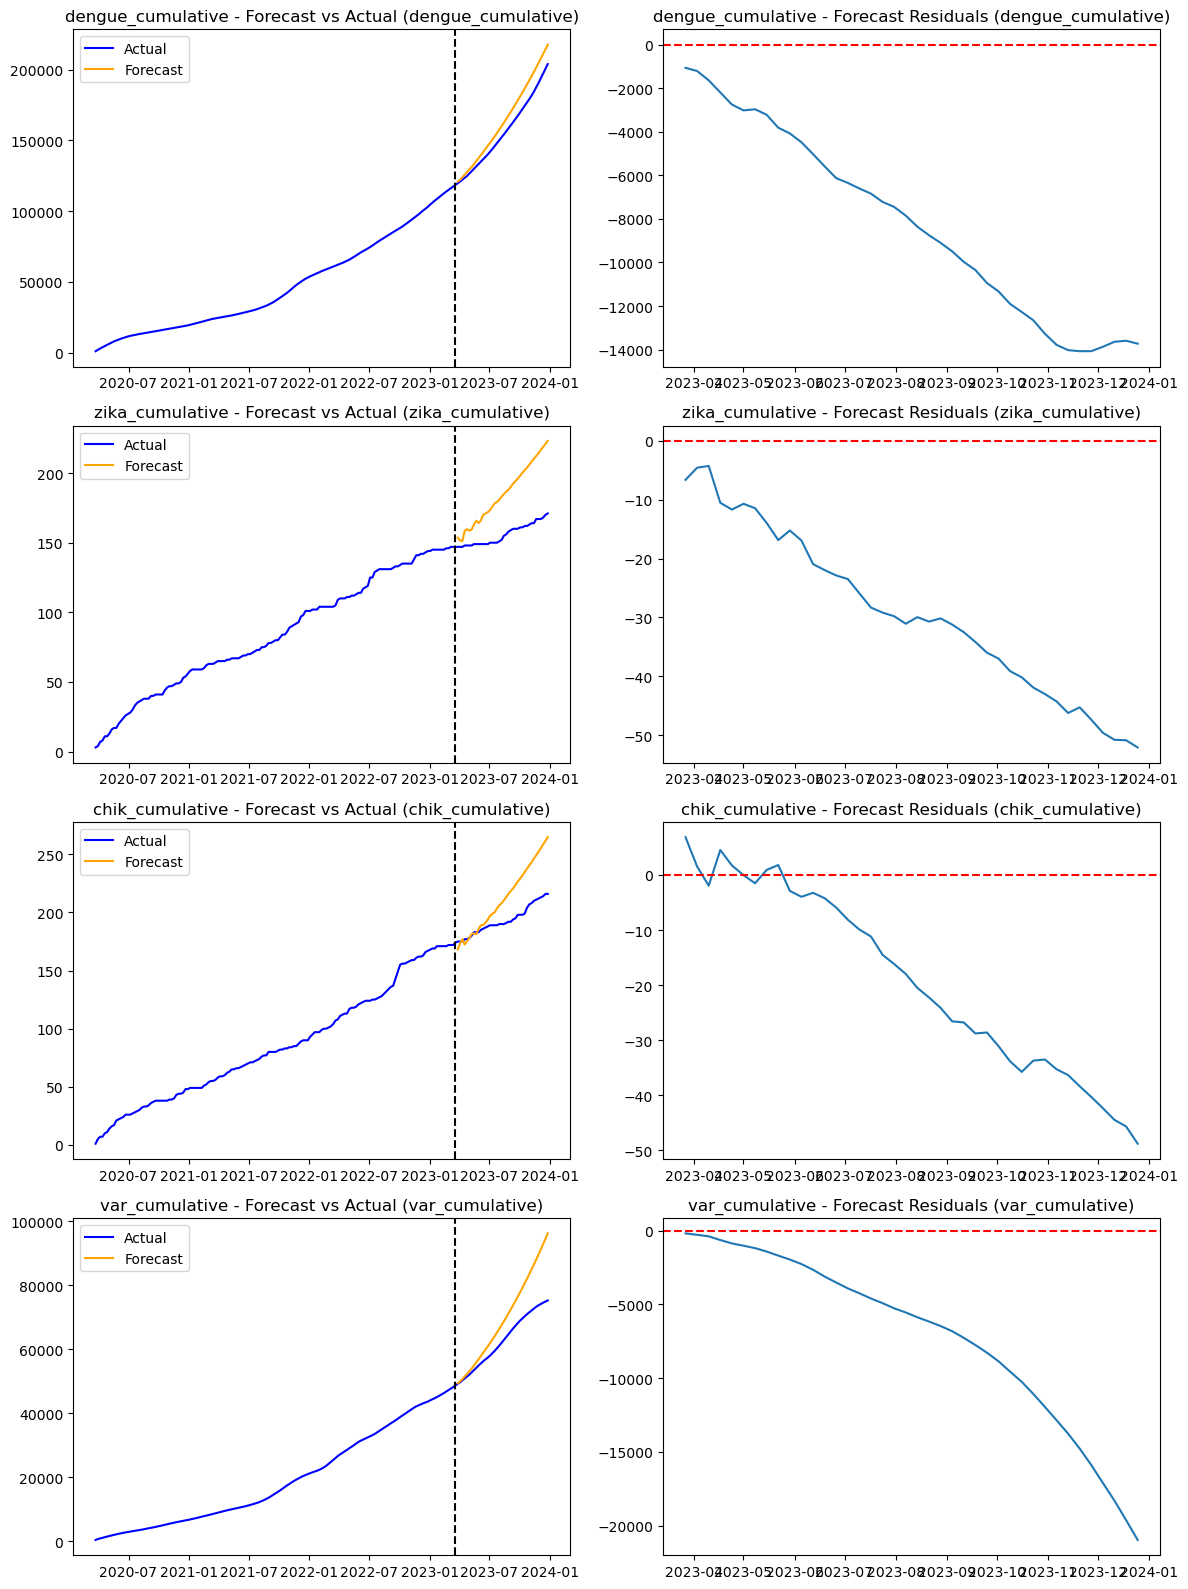

In [44]:
from statsmodels.tsa.api import VAR
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np
import matplotlib.pyplot as plt



dict_metrics = {}


fig, axs = plt.subplots(len(targets), 2, figsize=(12, 4 * len(targets)))

for idx, target in enumerate(targets):
    print(f"Processing disease: {target}")

    # filter by country
    

     # select variables
    df_var = df[['date',  target, 'tavg',
    'prcp', 'wspd', 'pres', 'mob_index', 
    'google_hospital', 'google_pharmacy', 'google_symptom']]
    df_var.set_index('date', inplace=True)

    
    # replace 0 to avoid log error
    df_var.replace(0, 1, inplace=True)

    df_original = df_var.copy()

    # log difference
    df_var_log = np.log(df_var).diff().dropna()

    # train-test split
    split_idx = int(len(df_var_log) * 0.8)
    df_train, df_test = df_var_log.iloc[:split_idx], df_var_log.iloc[split_idx:]

    # fit VAR model on training data
    model_l = VAR(df_train)
    results_l = model_l.fit(maxlags=5)

    # Forecasting
    lag_order = results_l.k_ar
    forecast_input = df_train.values[-lag_order:]
    forecast_steps = len(df_test)

    forecast_diff_log = results_l.forecast(y=forecast_input, steps=forecast_steps)
    forecast_diff_log_df = pd.DataFrame(forecast_diff_log, index=df_test.index, columns=df_test.columns)

    # Reverse transformations to original scale
    last_observed_log = np.log(df_original.iloc[split_idx])
    forecast_log = forecast_diff_log_df.cumsum() + last_observed_log
    forecast_original_scale = np.exp(forecast_log)
    actual_original_scale = df_original.iloc[split_idx+1:split_idx+1+forecast_steps]

    # Calculate performance metrics on original scale
    rmse = np.sqrt(mean_squared_error(actual_original_scale[target], forecast_original_scale[target]))
    r2 = r2_score(actual_original_scale[target], forecast_original_scale[target])

    dict_metrics[target] = {'rmse': rmse, 'r2': r2}

    # Plot actual vs forecast for target variable in original scale
    axs[idx, 0].plot(df_original[target], label='Actual', color='blue')
    axs[idx, 0].plot(forecast_original_scale[target], label='Forecast', color='orange')
    axs[idx, 0].axvline(df_original.index[split_idx], color='black', linestyle='--')
    axs[idx, 0].set_title(f'{target} - Forecast vs Actual ({target})')
    axs[idx, 0].legend()

    # Plot residuals in original scale
    residuals = actual_original_scale[target] - forecast_original_scale[target]
    axs[idx, 1].plot(residuals)
    axs[idx, 1].axhline(y=0, color='r', linestyle='--')
    axs[idx, 1].set_title(f'{target} - Forecast Residuals ({target})')

plt.tight_layout()
plt.show()

In [45]:
# Display metrics
metrics_df = pd.DataFrame(dict_metrics).T
metrics_df

,rmse,r2
dengue_cumulative,9258.502565,0.858322
zika_cumulative,32.335271,-17.065219
chik_cumulative,25.190166,-3.245084
var_cumulative,9143.965148,-0.198311


Processing disease: dengue_cumulative
Processing disease: zika_cumulative
Processing disease: chik_cumulative
Processing disease: var_cumulative


C:\Users\danie\AppData\Local\Temp\ipykernel_25120\3763922619.py:21: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_var.replace(0, 1, inplace=True)
c:\Users\danie\anaconda3\envs\thesis\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-MON will be used.
  self._init_dates(dates, freq)
C:\Users\danie\AppData\Local\Temp\ipykernel_25120\3763922619.py:21: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_var.replace(0, 1, inplace=True)
c:\Users\danie\anaconda3\envs\thesis\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning:

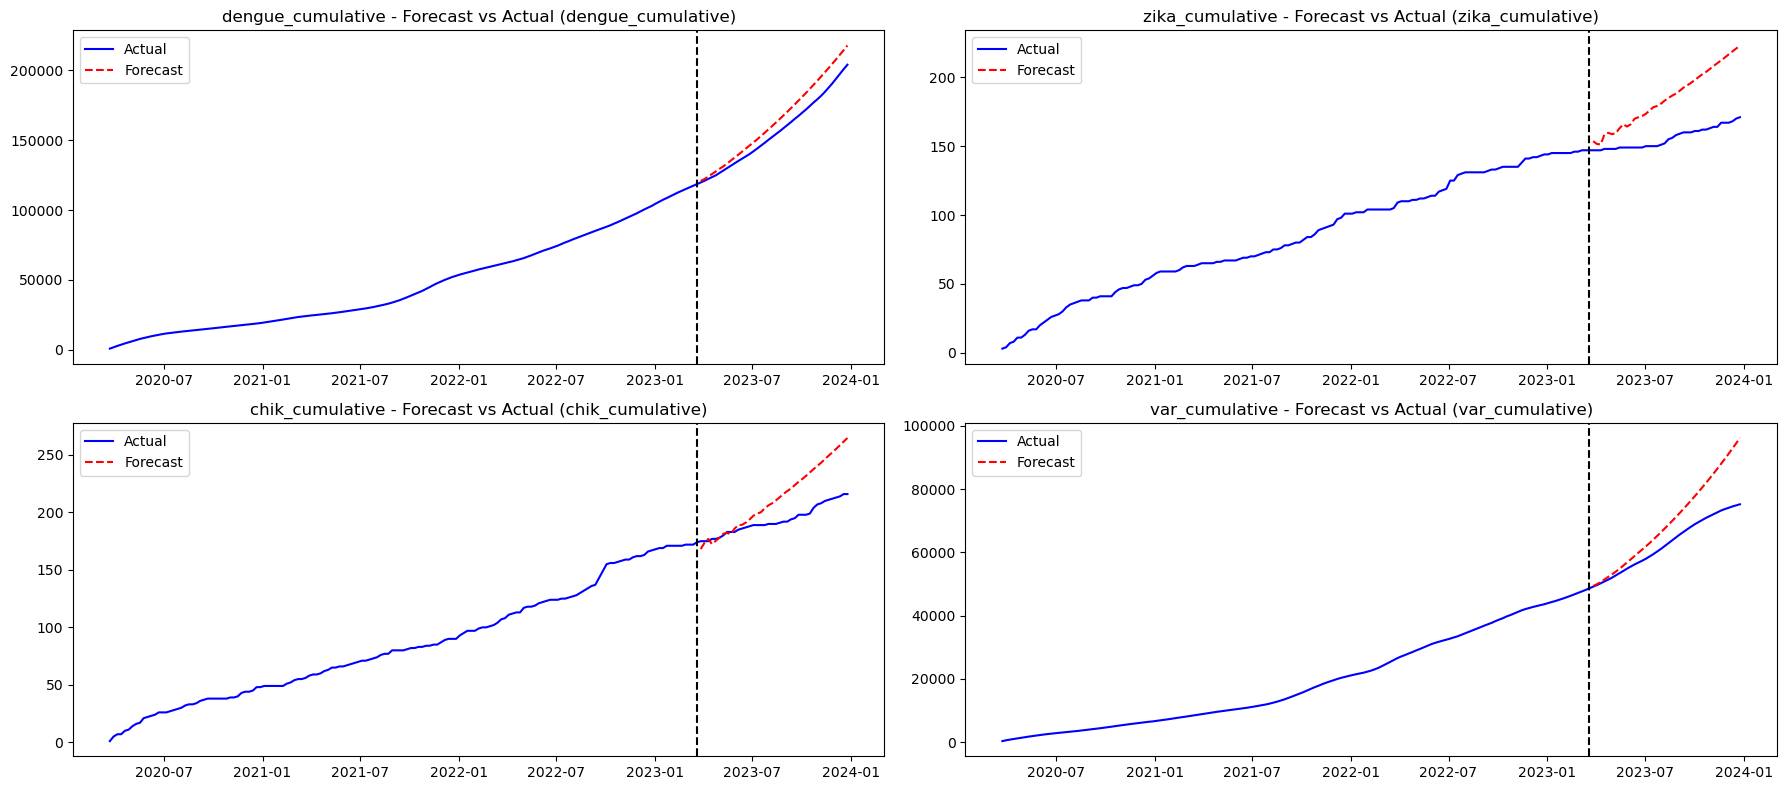

In [46]:


dict_metrics = {}


fig, axs = plt.subplots(2, 2, figsize=(18, 8))
axs = axs.flatten()

for idx, target in enumerate(targets):
    print(f"Processing disease: {target}")

    

    # select columns
    # select variables
    df_var = df[['date',  target, 'tavg',
    'prcp', 'wspd', 'pres', 'mob_index', 
    'google_hospital', 'google_pharmacy', 'google_symptom']]
    df_var.set_index('date', inplace=True)

    
    # replace 0 to avoid log error
    df_var.replace(0, 1, inplace=True)

    df_original = df_var.copy()

    # log difference
    df_var_log = np.log(df_var).diff().dropna()

    # train-test split
    split_idx = int(len(df_var_log) * 0.8)
    df_train, df_test = df_var_log.iloc[:split_idx], df_var_log.iloc[split_idx:]

    # fit VAR model on training data
    model_l = VAR(df_train)
    results_l = model_l.fit(maxlags=5)

    # Forecasting
    lag_order = results_l.k_ar
    forecast_input = df_train.values[-lag_order:]
    forecast_steps = len(df_test)

    forecast_diff_log = results_l.forecast(y=forecast_input, steps=forecast_steps)
    forecast_diff_log_df = pd.DataFrame(forecast_diff_log, index=df_test.index, columns=df_test.columns)

    # Reverse transformations to original scale
    last_observed_log = np.log(df_original.iloc[split_idx])
    forecast_log = forecast_diff_log_df.cumsum() + last_observed_log
    forecast_original_scale = np.exp(forecast_log)
    actual_original_scale = df_original.iloc[split_idx+1:split_idx+1+forecast_steps]

    # Calculate performance metrics on original scale
    rmse = np.sqrt(mean_squared_error(actual_original_scale[target], forecast_original_scale[target]))
    r2 = r2_score(actual_original_scale[target], forecast_original_scale[target])

    dict_metrics[target] = {'rmse': rmse, 'r2': r2}


    # Plot actual vs forecast for target variable in original scale
    axs[idx].plot(df_original[target], label='Actual', color='blue')
    axs[idx].plot(forecast_original_scale[target], label='Forecast', color='red', linestyle='--')
    axs[idx].axvline(df_original.index[split_idx], color='black', linestyle='--')
    axs[idx].set_title(f'{target} - Forecast vs Actual ({target})')
    axs[idx].legend()

# Adjust layout and remove any unused subplots
for j in range(len(targets), len(axs)):
    fig.delaxes(axs[j])

plt.tight_layout()
plt.show()

In [47]:
# Display metrics
metrics_df = pd.DataFrame(dict_metrics).T
metrics_df[['rmse']]

,rmse
dengue_cumulative,9258.502565
zika_cumulative,32.335271
chik_cumulative,25.190166
var_cumulative,9143.965148


## Feature Selection

In [48]:
dict_results

{'dengue_cumulative': array(['const', 'L1.dengue_cumulative', 'L2.dengue_cumulative', 'L3.pres',
        'L5.tavg'], dtype=object),
 'zika_cumulative': array(['L1.zika_cumulative', 'L1.prcp', 'L2.zika_cumulative', 'L2.pres',
        'L2.google_pharmacy', 'L3.zika_cumulative', 'L3.tavg',
        'L4.zika_cumulative', 'L4.tavg'], dtype=object),
 'chik_cumulative': array(['const', 'L2.pres', 'L3.chik_cumulative', 'L4.chik_cumulative',
        'L5.chik_cumulative'], dtype=object),
 'var_cumulative': array(['const', 'L1.var_cumulative'], dtype=object)}

Processing disease: dengue_cumulative
Processing disease: zika_cumulative
Processing disease: chik_cumulative
Processing disease: var_cumulative
Target 'var_cumulative' depends only on itself, forcing inclusion of 'tavg'


c:\Users\danie\anaconda3\envs\thesis\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-MON will be used.
  self._init_dates(dates, freq)
c:\Users\danie\anaconda3\envs\thesis\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-MON will be used.
  self._init_dates(dates, freq)
c:\Users\danie\anaconda3\envs\thesis\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-MON will be used.
  self._init_dates(dates, freq)
c:\Users\danie\anaconda3\envs\thesis\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-MON will be used.
  self._init_dates(dates, freq)


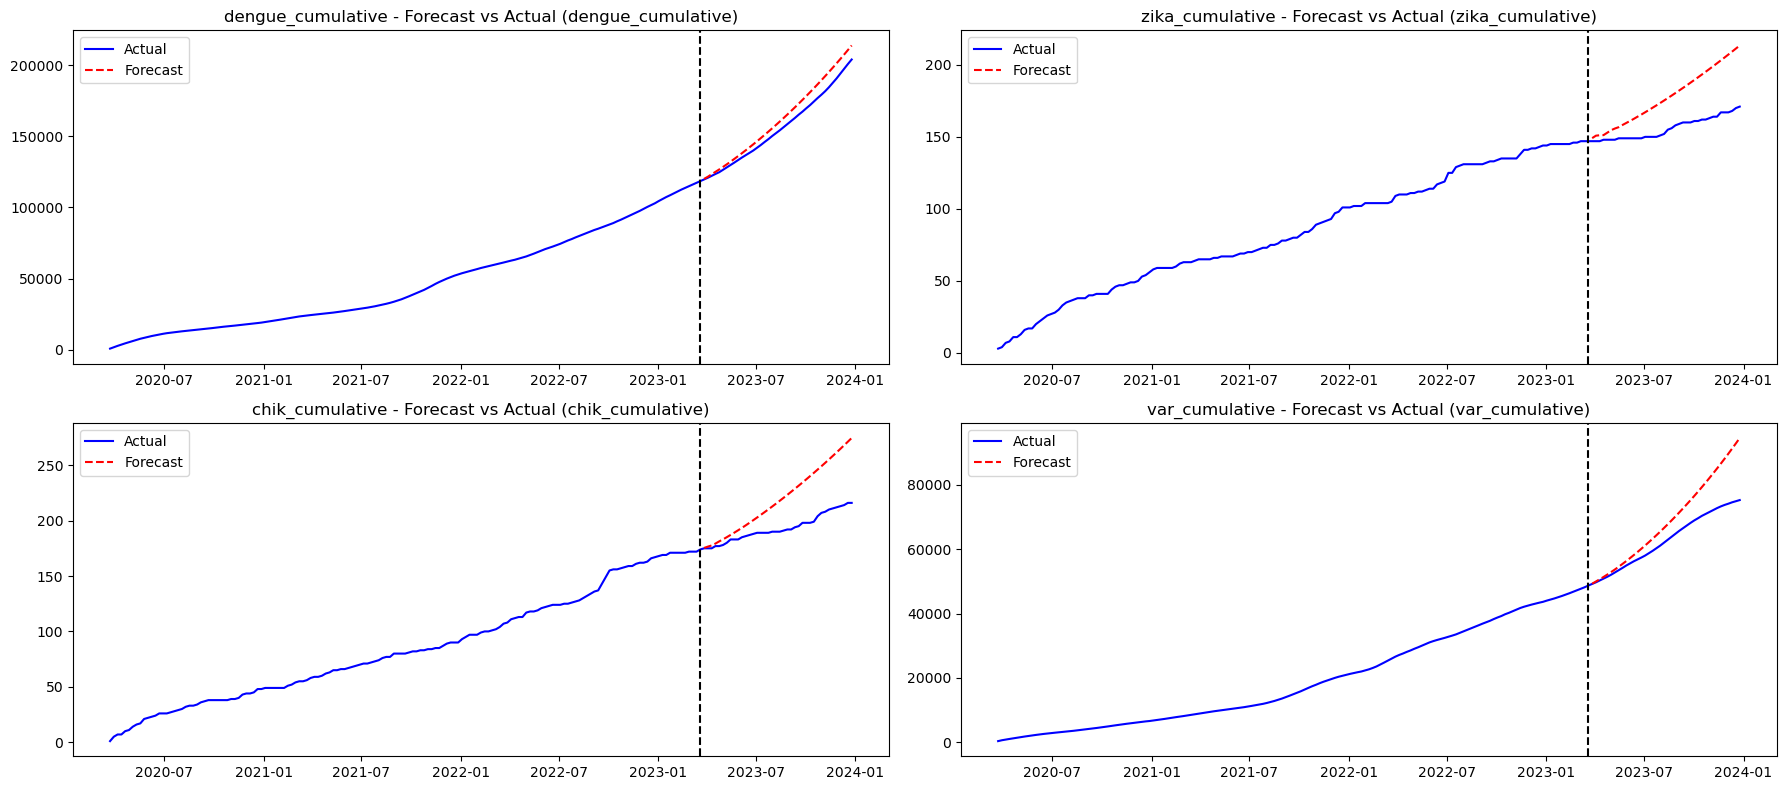

In [49]:




dict_metrics = {}

fig, axs = plt.subplots(2, 2, figsize=(18, 8))
axs = axs.flatten()

for idx, target in enumerate(targets):
    print(f"Processing disease: {target}")

    # filter by country
    df_var = df.copy()

    # select columns based on significant variables
    significant_vars = dict_results[target]

    columns_to_use = ['date', target]

    # Add relevant original variables (without lag prefix)
    available_vars = ['tavg', 'prcp', 'wspd', 'pres', 'mob_index', 
                      'google_hospital', 'google_pharmacy', 'google_symptom']

    # track whether at least one explanatory var is added
    explanatory_added = False

    for var in available_vars:
        if any(var in sig_var for sig_var in significant_vars):
            columns_to_use.append(var)
            if var != target:
                explanatory_added = True

    # If no explanatory variables were added, force inclusion of 'tavg'
    if not explanatory_added and 'tavg' not in columns_to_use:
        print(f"Target '{target}' depends only on itself, forcing inclusion of 'tavg'")
        columns_to_use.append('tavg')

    df_var = df_var[columns_to_use].copy()

    df_var.set_index('date', inplace=True)

    # replace 0 to avoid log error
    df_var.replace(0, 1, inplace=True)

    df_original = df_var.copy()

    # log difference
    df_var_log = np.log(df_var).diff().dropna()

    # train-test split
    split_idx = int(len(df_var_log) * 0.8)
    df_train, df_test = df_var_log.iloc[:split_idx], df_var_log.iloc[split_idx:]

    # fit VAR model on training data
    model_l = VAR(df_train)
    results_l = model_l.fit(maxlags=5)

    # Forecasting
    lag_order = results_l.k_ar
    forecast_input = df_train.values[-lag_order:]
    forecast_steps = len(df_test)

    forecast_diff_log = results_l.forecast(y=forecast_input, steps=forecast_steps)
    forecast_diff_log_df = pd.DataFrame(forecast_diff_log, index=df_test.index, columns=df_test.columns)

    # Reverse transformations to original scale
    last_observed_log = np.log(df_original.iloc[split_idx])
    forecast_log = forecast_diff_log_df.cumsum() + last_observed_log
    forecast_original_scale = np.exp(forecast_log)
    actual_original_scale = df_original.iloc[split_idx+1:split_idx+1+forecast_steps]

    # Calculate performance metrics on original scale
    rmse = np.sqrt(mean_squared_error(actual_original_scale[target], forecast_original_scale[target]))
    r2 = r2_score(actual_original_scale[target], forecast_original_scale[target])

    dict_metrics[target] = {'rmse': rmse, 'r2': r2}

    # Plot actual vs forecast for target variable in original scale
    axs[idx].plot(df_original[target], label='Actual', color='blue')
    axs[idx].plot(forecast_original_scale[target], label='Forecast', color='red', linestyle='--')
    axs[idx].axvline(df_original.index[split_idx], color='black', linestyle='--')
    axs[idx].set_title(f'{target} - Forecast vs Actual ({target})')
    axs[idx].legend()

# Adjust layout and remove any unused subplots
for j in range(len(targets), len(axs)):
    fig.delaxes(axs[j])

plt.tight_layout()
plt.show()




In [50]:
metrics_df = pd.DataFrame(dict_metrics).T
metrics_df[['rmse']]

,rmse
dengue_cumulative,6894.866608
zika_cumulative,25.013144
chik_cumulative,31.725518
var_cumulative,8147.087875


## Hybrid model

1. Fit a GGM on each country
2. Use that as a covariate 
3. Fit a VAR using the GGM fitted values as covariate
4. See the results